# Principal component analysis from scratch (a.k.a. empirical orthogonal functions)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eabarnes1010/course_objective_analysis/blob/main/code/eof_from_scratch.ipynb)

*Elizabeth A. Barnes — BU Earth & Environment — Last updated: 2026-05-27*

## Learning objectives

- Walk through a principal component analysis (PCA) calculation end-to-end without using a library shortcut.
- See why standardizing variables matters when they have very different physical scales.
- Map a leading PC back into physical space (here, onto the 50 U.S. states) to interpret what the mode is telling you.

*Note on terminology: in the atmospheric sciences, principal components are often called "empirical orthogonal functions" (EOFs). The math is the same; this notebook uses PCA terminology throughout.*


## Setup

In [1]:
try:
    import google.colab

    IN_COLAB = True
except ImportError:
    IN_COLAB = False
print(f"IN_COLAB = {IN_COLAB}")

IN_COLAB = False


In [2]:
if IN_COLAB:
    # cartopy is preinstalled on modern Colab; if not, fall back to pip.
    try:
        import cartopy  # noqa: F401
    except ImportError:
        get_ipython().system("pip install cartopy")

import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io as sio

mpl.rcParams["figure.dpi"] = 100
plt.rc("font", size=12, weight="normal", family="sans-serif")
plt.rc("axes", titlesize=13, titleweight="bold")

# Reproducibility for the optional random-data path.
SEED = 655
rng = np.random.default_rng(SEED)


## Data description

The dataset is 7 weather variables averaged over one year for each of the 50 U.S. states. We can optionally swap in a matrix of random numbers to confirm that what we see is structure in the data, not an artifact of the method.

In [3]:
# Set to True to replace the real data with random numbers (sanity check).
FAKE_DATA = False

In [4]:
descriptor_names = [
    "temp", "precip", "% sun", "sun hours", "clear dys", "humid AM", "humid PM",
]

if IN_COLAB:
    get_ipython().system(
        "wget -q https://github.com/eabarnes1010/course_objective_analysis/raw/main/data/state_data_raw.mat"
    )
    DATA = sio.loadmat("state_data_raw.mat")
else:
    DATA = sio.loadmat("../data/state_data_raw.mat")
Y = DATA["X"]

if FAKE_DATA:
    Y = rng.random(Y.shape)


In [5]:
# Rows = U.S. states; columns = annual-mean weather variables.
df = pd.DataFrame(Y, columns=descriptor_names)
df

,temp,precip,% sun,sun hours,clear dys,humid AM,humid PM
0,62.8,58.3,58.0,2641.0,99.0,84.0,52.0
1,26.6,22.5,41.0,2061.0,61.0,77.0,64.0
2,60.3,13.6,85.0,3806.0,193.0,53.0,25.0
3,60.4,50.6,61.0,2771.0,123.0,85.0,49.0
4,59.4,22.2,68.0,3055.0,146.0,76.0,62.0
5,45.1,15.9,71.0,3204.0,136.0,60.0,35.0
6,49.0,50.3,56.0,2585.0,82.0,79.0,52.0
7,55.3,45.7,NaN,NaN,97.0,79.0,54.0
8,70.7,54.5,66.0,2927.0,101.0,87.0,57.0
9,63.5,50.7,66.0,2986.0,112.0,86.0,50.0


## Build anomalies, then standardize

Two decisions matter before doing PCA on mixed-unit data:

1. **Subtract the mean** of each variable so we work with anomalies.
2. **Standardize** by each variable's standard deviation. Without this, the variable with the largest numeric range would dominate the leading PC simply because it has more variance in its native units.

If you want to see what *not* standardizing does, replace `Xw = X / Xstd` with `Xw = X`.


In [6]:
# Anomalies from the state-mean (sample-mean).
Ymean = np.nanmean(Y, axis=0)
X = Y - Ymean

# Standardize so each variable has unit variance.
Xstd = np.nanstd(X, axis=0)
Xw = X / Xstd

## Covariance matrix and eigendecomposition

We form the variable-by-variable covariance matrix and diagonalize it. The eigenvectors are the **principal components (PCs)** in the variable space; the eigenvalues are their variances.

The custom `nandot` below is a NaN-safe substitute for `X.T @ Y / M` — handy because the raw data may contain missing values.

In [7]:
def nandot(X, Y):
    """NaN-safe (1/M) * X @ Y. Returns a matrix the same shape as X @ Y."""
    C = np.empty((X.shape[0], Y.shape[1]))
    for row in range(X.shape[0]):
        for col in range(Y.shape[1]):
            C[row, col] = np.nanmean(X[row, :] * Y[:, col])
    return C

In [8]:
# 7x7 covariance matrix. If there are no NaNs, this is equivalent to
#     C = Xw.T @ Xw / Xw.shape[0]
C = nandot(Xw.T, Xw)
print(C)

[[ 1.          0.54408661  0.4414842   0.32948218  0.37458539  0.21872046
  -0.10306989]
 [ 0.54408661  1.         -0.33037555 -0.47090245 -0.39337431  0.64439514
   0.5403986 ]
 [ 0.4414842  -0.33037555  1.          0.9785408   0.89338975 -0.59804246
  -0.81286433]
 [ 0.32948218 -0.47090245  0.9785408   1.          0.92730696 -0.61577507
  -0.86866918]
 [ 0.37458539 -0.39337431  0.89338975  0.92730696  1.         -0.52428887
  -0.77892432]
 [ 0.21872046  0.64439514 -0.59804246 -0.61577507 -0.52428887  1.
   0.7324305 ]
 [-0.10306989  0.5403986  -0.81286433 -0.86866918 -0.77892432  0.7324305
   1.        ]]


In [9]:
# Eigenvalues (lam: 7,) and eigenvectors (E: 7x7).
lam, E = np.linalg.eig(C)

# Sort from largest to smallest eigenvalue.
order = np.argsort(lam)[::-1]
lam = lam[order]
E = E[:, order]

# Convert to percent variance explained.
pve = 100.0 * lam / np.sum(lam)

## Eigenvalue spectrum

Each bar is one PC. The error bars use the North et al. (1982) rule of thumb, $\delta\lambda \approx \lambda \sqrt{2/N^*}$, with $N^* = N$ (i.e. assuming the 50 states are independent samples — a debatable assumption).

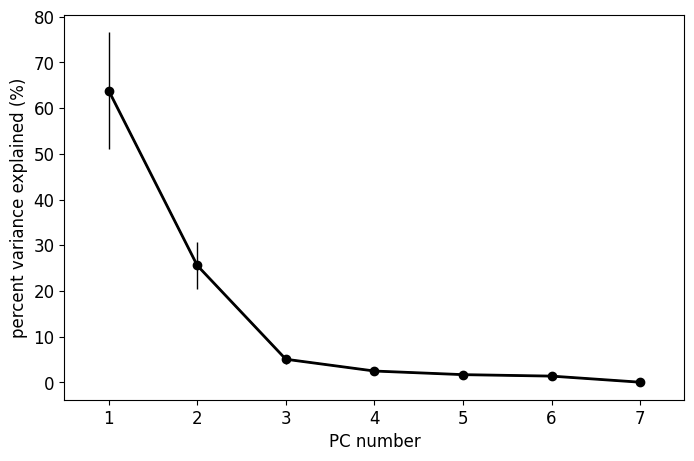

In [10]:
Nstar = X.shape[0]
eb = pve * np.sqrt(2.0 / Nstar)
positions = np.arange(1, pve.size + 1)

plt.figure(figsize=(8, 5))
plt.plot(positions, pve, "o-", linewidth=2, color="black")
plt.errorbar(positions, pve, yerr=eb, xerr=None, linewidth=1, color="black")
plt.xlim(0.5, 7.5)
plt.xlabel("PC number")
plt.ylabel("percent variance explained (%)")
plt.show()

## Project the data onto a chosen PC

Pick a PC of interest (`pc_num`), grab its eigenvector, and project the standardized data onto it to get the **PC time series** (here, one value per state). We then build two convenient versions of the spatial pattern:

- `d_std` — the PC pattern in standardized units (a regression of `Xw` onto the standardized PC time series).
- `d_phys` — the same pattern, but expressed in the variables' physical units.

In [11]:
# Which PC do you want to look at?
pc_num = 1

e1 = E[:, pc_num - 1]  # 7-vector
z1 = Xw @ e1  # PC time series, one value per state
z1 = (z1 - np.nanmean(z1)) / np.nanstd(z1)  # standardize z1

# Spatial patterns (NaN-safe regression onto z1).
d_phys = nandot(z1[np.newaxis, :], X).T  # physical units
d_std = nandot(z1[np.newaxis, :], Xw).T  # standardized units

## Plot the PC pattern in standardized units

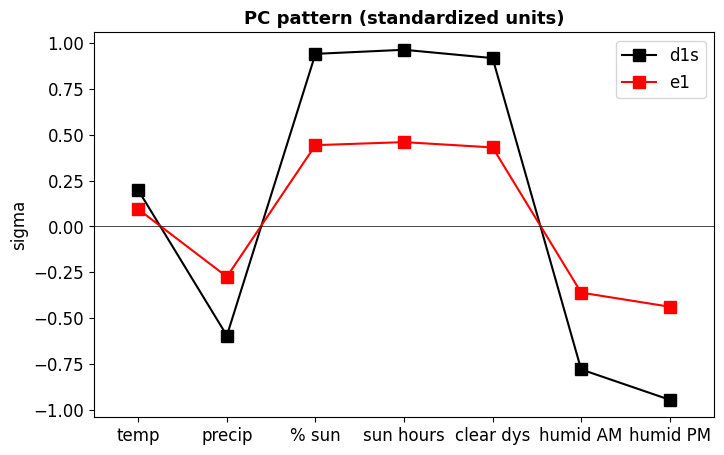

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(d_std, "s-k", label=f"d{pc_num}s", markersize=8)
plt.plot(e1, "s-r", label=f"e{pc_num}", markersize=8)

plt.xticks(np.arange(len(descriptor_names)), descriptor_names, fontsize=12)
plt.xlim(-0.5, 6.5)
plt.axhline(color="k", linewidth=0.5)
plt.legend()
plt.ylabel("sigma")
plt.title("PC pattern (standardized units)")
plt.show()

## Plot the PC pattern in physical units

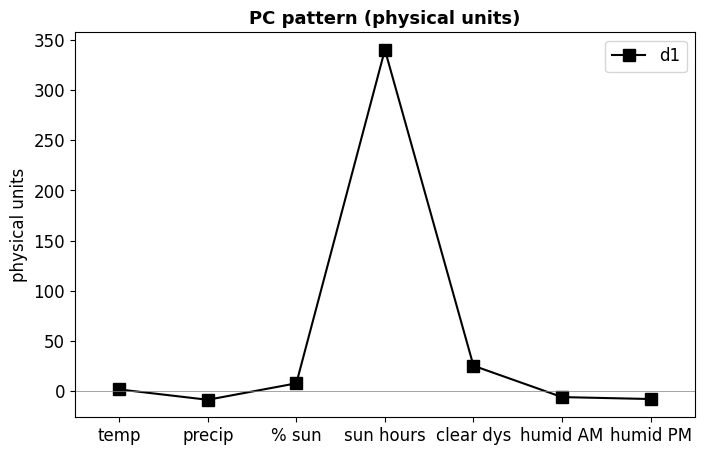

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(d_phys, "s-k", label=f"d{pc_num}", markersize=8)

plt.xticks(np.arange(len(descriptor_names)), descriptor_names)
plt.xlim(-0.5, 6.5)
plt.axhline(color="gray", linewidth=0.5)
plt.legend()
plt.ylabel("physical units")
plt.title("PC pattern (physical units)")
plt.show()

## Project the PC time series onto a U.S. map

The PC time series `z1` has one value per state — so we can paint each state by its PC value to *see* which states the leading mode emphasizes.

The state polygons come from [Natural Earth](https://www.naturalearthdata.com/downloads/110m-cultural-vectors/) (110 m, admin-1 states/provinces).

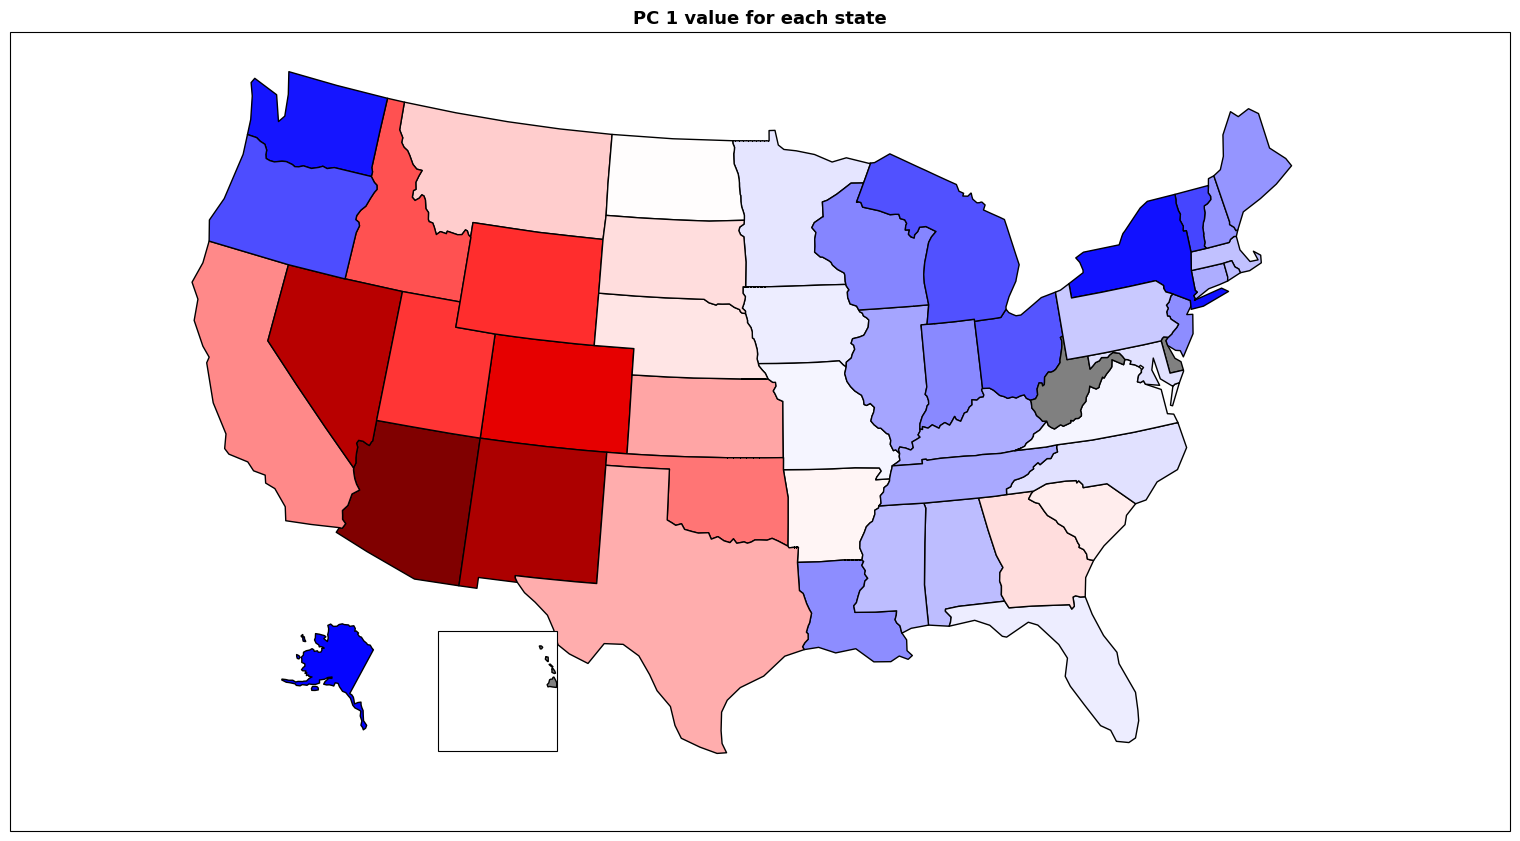

In [14]:
fig = plt.figure(figsize=(15, 8))
ax = fig.add_axes([0, 0, 1, 1], projection=ccrs.LambertConformal())

plt.title(f"PC {pc_num} value for each state")
ax.set_extent([-125, -66.5, 20, 50], ccrs.Geodetic())

states_shp = shpreader.natural_earth(
    resolution="110m",
    category="cultural",
    name="admin_1_states_provinces",
)
cmap = plt.get_cmap("seismic")
vmin, vmax = -3.0, 3.0

# Build the ordered list of state names, dropping DC.
state_names = sorted(
    {rec.attributes["name"] for rec in shpreader.Reader(states_shp).records()}
)
state_names.remove("District of Columbia")

for rec in shpreader.Reader(states_shp).records():
    statename = rec.attributes["name"]
    if statename == "District of Columbia":
        continue

    z = z1[state_names.index(statename)]
    clr = cmap((z - vmin) / (vmax - vmin))[:3] if not np.isnan(z) else "gray"

    if statename == "Alaska":
        axak = fig.add_axes([0.1, 0.1, 0.2, 0.2], projection=ccrs.LambertConformal())
        axak.set_extent([-185, -130, 70, 50])
        axak.add_geometries(
            [rec.geometry],
            ccrs.PlateCarree(),
            facecolor=clr,
            edgecolor="k",
        )
    elif statename == "Hawaii":
        axhi = fig.add_axes([0.25, 0.1, 0.15, 0.15], projection=ccrs.LambertConformal())
        axhi.set_extent([-155, -165, 10, 20])
        axhi.add_geometries(
            [rec.geometry],
            ccrs.PlateCarree(),
            facecolor=clr,
            edgecolor="k",
        )
    else:
        ax.add_geometries(
            [rec.geometry],
            ccrs.PlateCarree(),
            facecolor=clr,
            edgecolor="k",
        )

plt.box(False)
plt.show()

These per-state PC values show how strongly each state "looks like" the PC pattern above. Dark red and dark blue are large opposite-signed values — the absolute sign is arbitrary; what matters is the *relationship* between states.

## Wrap-up

The recipe in this notebook (anomalies → standardize → covariance → eigendecomposition → project → map back to physical space) is the same recipe used for atmospheric and oceanographic EOFs on much larger fields. The only thing that changes for a real climate dataset is the size of the matrices.